# Notebook 2 — Graph Construction
### Indoor Air Pollution Detection via Ontology-driven Graph Neural Networks

This notebook turns the cleaned data (Notebook 0) and the ontology edges (Notebook 1) into the
**single graph substrate** that both downstream tasks run on:

- **Detection (headline)** — a GNN autoencoder reconstructs every node's window-features;
  reconstruction error is the anomaly signal. Trained on **normal windows only**, evaluated on the
  three known events.
- **Prediction (comparison, Xuanzhe-style)** — predict the 9 pollutant concentrations from a
  **leakage-clean context** set, routed through the same ontology graph. GNN vs RNN/LSTM/GRU.

**The graph (this is the key design choice).** Nodes are the **30 sensor variables**; edges are the
**ontology relations** from `ontology_edges.csv`. So the ontology genuinely *is* the topology — the
same graph for both tasks. A "sample" is one **time-window**: the 30 nodes keep the same identity and
the same edges, only their feature vectors change window to window.

**What this fixes from the earlier pipeline** (the problems found in the review):
- *Ontology now drives the model* — edges come from the OWL relations, not from temporal/correlation
  heuristics. Previously the ontology was exported and never used.
- *PM-from-counts leakage removed* — the particle-count bins are excluded from the **prediction**
  inputs (PM mass is computed from those same bins). For detection, that coupling is kept on purpose —
  it is how "normal" is defined.
- *No look-ahead* — edges are static ontology relations, not correlations computed over future windows.
- *Honest splits* — per-deployment and temporal; events held out correctly; not the location-confounded
  70/15/15 slice that put the whole apartment in train.

Output is portable **`.npz` + `manifest.json`** (numpy only — no torch here), so it runs on any laptop;
Notebook 3 wraps it into PyG `Data`.


In [1]:
import json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
np.random.seed(42)
print("numpy", np.__version__, "| pandas", pd.__version__)

numpy 2.4.6 | pandas 3.0.3


## 1. Load Notebook 0 + Notebook 1 outputs

In [2]:
_C = [Path("processed"), Path("."), Path("/mnt/user-data/uploads")]
PROC = next((p for p in _C if (p / "config.json").exists()), Path("processed"))
ONTO_DIR = PROC / "ontology"
GRAPH_DIR = PROC / "graph"
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

cfg = json.load(open(PROC / "config.json"))
VARS      = cfg["variables"]                 # 30 variables, fixed node order
CATEGORY  = cfg["category"]
STATE_LEVELS = cfg["state_levels"]
WIN       = cfg["window"]
SIZE, STRIDE, MAX_GAP = WIN["size"], WIN["stride"], WIN["max_gap_frac"]

edges_df = pd.read_csv(ONTO_DIR / "ontology_edges.csv")   # src, relation, dst, ... (with symmetric reverses)

clean = {"laboratory": pd.read_csv(PROC / "laboratory_clean.csv", parse_dates=["timestamp"]),
         "apartment":  pd.read_csv(PROC / "apartment_clean.csv",  parse_dates=["timestamp"])}
states = {"laboratory": pd.read_csv(PROC / "laboratory_states.csv", parse_dates=["timestamp"]),
          "apartment":  pd.read_csv(PROC / "apartment_states.csv",  parse_dates=["timestamp"])}

NODE_INDEX = {v: i for i, v in enumerate(VARS)}
N_NODES = len(VARS)
print(f"{N_NODES} variable-nodes | window size={SIZE} stride={STRIDE} | ontology edges file: {len(edges_df)} rows")

30 variable-nodes | window size=30 stride=15 | ontology edges file: 57 rows


## 2. Build the edge index from the ontology

Map each ontology relation to a directed edge between variable-nodes. The file already carries the
reverse direction for symmetric relations (`correlatedWith`, `associatedWith`), so this is the exact
graph topology — shared by every window.


In [3]:
rel_vocab = {r: i for i, r in enumerate(sorted(edges_df["relation"].unique()))}
src = edges_df["src"].map(NODE_INDEX).values
dst = edges_df["dst"].map(NODE_INDEX).values
edge_index = np.vstack([src, dst]).astype(np.int64)          # (2, E)
edge_type  = edges_df["relation"].map(rel_vocab).values.astype(np.int64)  # (E,)
edge_weight = np.ones(edge_index.shape[1], dtype=np.float32)  # (E,) uniform; models may re-weight

assert edge_index.max() < N_NODES and edge_index.min() >= 0
deg = np.bincount(edge_index[0], minlength=N_NODES)
print(f"Directed edges: {edge_index.shape[1]} | relation types: {list(rel_vocab)}")
print(f"Node degree — min {deg.min()}, max {deg.max()}, mean {deg.mean():.1f}  (0 would mean an isolated node)")

Directed edges: 57 | relation types: ['affects', 'associatedWith', 'correlatedWith', 'indicates', 'influences', 'reflects']
Node degree — min 1, max 5, mean 1.9  (0 would mean an isolated node)


## 3. Window the data and engineer node features

Each window is `SIZE` consecutive 2-minute samples (≈1 h). For every variable-node we compute **8
feature channels** over the window: `mean, std, min, max, last, slope, range`, plus a `state_sev`
channel = the mean ordinal air-quality state (`Excellent`=0 … `Dangerous`=1) — this is how the
ontology's semantic state enters the node features. Gaps inside a usable window (<20% missing) are
filled with the window's own column mean before the stats are taken.


In [4]:
FEATURES = ["mean", "std", "min", "max", "last", "slope", "range", "state_sev"]
F = len(FEATURES)
STATE_ORD = {s: i / (len(STATE_LEVELS) - 1) for i, s in enumerate(STATE_LEVELS)}  # 0..1

def window_block_features(block, state_block):
    """block: (L, N) raw values (may contain NaN). state_block: (L, N) ordinal 0..1 (may be NaN)."""
    L = block.shape[0]
    colmean = np.nanmean(block, axis=0)
    colmean = np.where(np.isnan(colmean), 0.0, colmean)
    filled = np.where(np.isnan(block), colmean, block)            # (L, N)
    x = np.arange(L, dtype=float); xc = x - x.mean(); denom = (xc ** 2).sum() or 1.0
    yc = filled - filled.mean(0)
    slope = (xc[:, None] * yc).sum(0) / denom
    sev = np.nanmean(state_block, axis=0); sev = np.where(np.isnan(sev), 0.5, sev)
    feats = np.stack([filled.mean(0), filled.std(0), filled.min(0), filled.max(0),
                      filled[-1], slope, filled.max(0) - filled.min(0), sev], axis=1)  # (N, F)
    return feats

def majority_event(ev_slice):
    nz = [e for e in ev_slice if e != "normal"]
    return max(set(nz), key=nz.count) if nz else "normal"

EVENT_ID = {"normal": 0, "fire": 1, "dust_humidity": 2, "power_outage": 3}

X_raw, ev_ids, locs, starts, gapfracs = [], [], [], [], []
for loc in ["laboratory", "apartment"]:
    df = clean[loc].sort_values("timestamp").reset_index(drop=True)
    st = states[loc].sort_values("timestamp").reset_index(drop=True)
    vals = df[VARS].values.astype(float)
    sord = np.vectorize(lambda s: STATE_ORD.get(s, np.nan))(st[VARS].values.astype(object))
    gap = df[VARS].isna().all(axis=1).values
    ev = df["event"].values
    ts = df["timestamp"].values
    n = len(df)
    for s in range(0, n - SIZE + 1, STRIDE):
        e = s + SIZE
        gf = float(gap[s:e].mean())
        if gf > MAX_GAP:
            continue
        X_raw.append(window_block_features(vals[s:e], sord[s:e]))
        ev_ids.append(EVENT_ID[majority_event(ev[s:e])])
        locs.append(loc); starts.append(str(ts[s])); gapfracs.append(round(gf, 3))

X_raw = np.array(X_raw, dtype=np.float32)        # (W, N, F)
ev_ids = np.array(ev_ids, dtype=np.int64)
locs = np.array(locs); starts = np.array(starts)
W = X_raw.shape[0]
print(f"Usable windows: {W}  | feature tensor X = {X_raw.shape}  (windows, nodes, channels)")
for loc in ["laboratory", "apartment"]:
    m = locs == loc
    vc = {k: int((ev_ids[m] == v).sum()) for k, v in EVENT_ID.items()}
    print(f"  {loc:11s}: {m.sum():4d} windows | events {vc}")

Usable windows: 4258  | feature tensor X = (4258, 30, 8)  (windows, nodes, channels)
  laboratory : 3426 windows | events {'normal': 3342, 'fire': 50, 'dust_humidity': 0, 'power_outage': 34}
  apartment  :  832 windows | events {'normal': 782, 'fire': 0, 'dust_humidity': 50, 'power_outage': 0}


## 4. Splits — per-deployment, temporal, leakage-aware

**Detection**: train/val are **normal windows only** (the autoencoder must learn normality), split
70/15/15 in time within each deployment; the held-out 15% of normal windows **plus every event
window** form the detection test set (so we measure both false positives and event recall).

**Prediction**: normal windows only (the July-9 PM spike is a sensor *artifact*, not real pollution,
so it must not be a regression target), the same per-deployment 70/15/15 temporal split.


In [5]:
det_train = np.zeros(W, bool); det_val = np.zeros(W, bool); det_test = np.zeros(W, bool)
pred_train = np.zeros(W, bool); pred_val = np.zeros(W, bool); pred_test = np.zeros(W, bool)

for loc in ["laboratory", "apartment"]:
    idx = np.where(locs == loc)[0]                 # contiguous, time-ordered
    is_ev = ev_ids[idx] != 0
    normal = idx[~is_ev]; events = idx[is_ev]
    a, b = int(len(normal) * 0.70), int(len(normal) * 0.85)
    det_train[normal[:a]] = True; det_val[normal[a:b]] = True; det_test[normal[b:]] = True
    det_test[events] = True
    pred_train[normal[:a]] = True; pred_val[normal[a:b]] = True; pred_test[normal[b:]] = True

print("Detection  split — train/val/test:", int(det_train.sum()), int(det_val.sum()), int(det_test.sum()),
      f"(test includes {int((ev_ids[det_test]!=0).sum())} event windows)")
print("Prediction split — train/val/test:", int(pred_train.sum()), int(pred_val.sum()), int(pred_test.sum()),
      "(normal windows only)")

Detection  split — train/val/test: 2886 618 754 (test includes 134 event windows)
Prediction split — train/val/test: 2886 618 620 (normal windows only)


## 5. Standardise node features (per-node, train-only stats)

Each variable's 7 numeric channels are standardised using **only the detection-train (normal)**
windows, per node — so co2 (hundreds of ppm) and pm2_5 (near zero) end up on comparable scales. The
`state_sev` channel is already 0–1 and left as is. Stats are saved for inverse use later.


In [6]:
num = X_raw[:, :, :7]                                   # (W, N, 7) numeric channels
tr = det_train
mu = num[tr].mean(axis=0)                              # (N, 7) per-node, per-channel
sd = num[tr].std(axis=0); sd[sd < 1e-8] = 1.0
X = X_raw.copy()
X[:, :, :7] = (num - mu) / sd                          # standardised; channel 7 untouched
print("Standardised node features with per-node train stats. X mean(train)≈",
      round(float(X[tr][:, :, :7].mean()), 4))

Standardised node features with per-node train stats. X mean(train)≈ 0.0


## 6. Prediction task — targets + leakage-clean inputs

The 9 **target pollutants** are predicted from a **context** set that deliberately excludes anything
that trivially encodes them: the particle counts and `TypPS` (same optical sensor as PM mass),
`dCO2dt` (the CO2 derivative), and the composite `health`/`performance` indices. Targets are stored in
**real units** (for RMSE in ppm / µg/m³ / ppb, matching Xuanzhe) and standardised separately.


In [7]:
TARGET_POLLUTANTS = ["co2", "so2", "no2", "co", "o3", "tvoc", "pm2_5", "pm10", "pm1"]
CONTEXT_VARS = ["temperature", "temperature_o2", "humidity", "humidity_abs", "dewpt",
                "pressure", "oxygen", "sound", "sound_max", "dHdt"]
EXCLUDED = [v for v in VARS if v not in TARGET_POLLUTANTS and v not in CONTEXT_VARS]

target_idx  = np.array([NODE_INDEX[v] for v in TARGET_POLLUTANTS])
context_idx = np.array([NODE_INDEX[v] for v in CONTEXT_VARS])

# Targets in real units = raw window-mean (channel 0) of the 9 pollutant nodes
Y_raw = X_raw[:, target_idx, 0].astype(np.float32)     # (W, 9)
ptr = pred_train
Ymu = Y_raw[ptr].mean(0); Ysd = Y_raw[ptr].std(0); Ysd[Ysd < 1e-8] = 1.0
Y_std = (Y_raw - Ymu) / Ysd

print(f"Targets ({len(TARGET_POLLUTANTS)}): {TARGET_POLLUTANTS}")
print(f"Context inputs ({len(CONTEXT_VARS)}): {CONTEXT_VARS}")
print(f"Excluded from prediction ({len(EXCLUDED)}, leakage / non-pollutant): {EXCLUDED}")
assert len(TARGET_POLLUTANTS) + len(CONTEXT_VARS) + len(EXCLUDED) == N_NODES

Targets (9): ['co2', 'so2', 'no2', 'co', 'o3', 'tvoc', 'pm2_5', 'pm10', 'pm1']
Context inputs (10): ['temperature', 'temperature_o2', 'humidity', 'humidity_abs', 'dewpt', 'pressure', 'oxygen', 'sound', 'sound_max', 'dHdt']
Excluded from prediction (11, leakage / non-pollutant): ['TypPS', 'cnt0_5', 'performance', 'measuretime', 'cnt5', 'cnt1', 'cnt10', 'dCO2dt', 'health', 'cnt2_5', 'cnt0_3']


## 7. Quick visual check — window counts by split

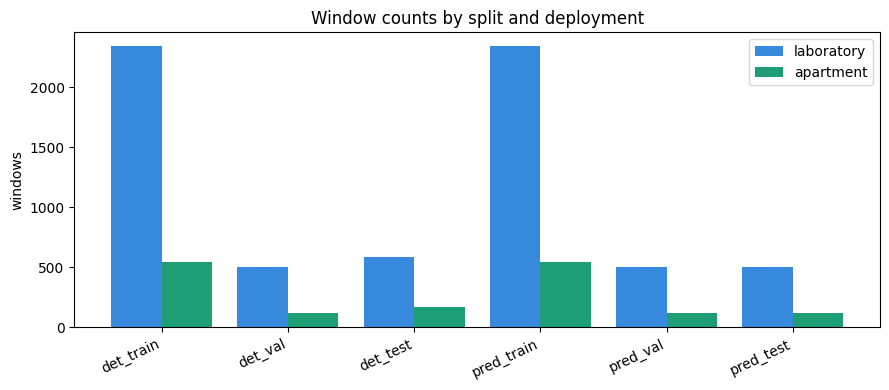

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
splits = {"det_train": det_train, "det_val": det_val, "det_test": det_test,
          "pred_train": pred_train, "pred_val": pred_val, "pred_test": pred_test}
lab_counts = [int((s & (locs == "laboratory")).sum()) for s in splits.values()]
apt_counts = [int((s & (locs == "apartment")).sum()) for s in splits.values()]
xs = np.arange(len(splits))
ax.bar(xs - 0.2, lab_counts, width=0.4, label="laboratory", color="#378ADD")
ax.bar(xs + 0.2, apt_counts, width=0.4, label="apartment", color="#1D9E75")
ax.set_xticks(xs); ax.set_xticklabels(list(splits), rotation=25, ha="right")
ax.set_ylabel("windows"); ax.set_title("Window counts by split and deployment")
ax.legend(); fig.tight_layout(); plt.show()

## 8. Save the graph substrate

One compressed `.npz` with the node features, ontology edges, both label sets, both split masks, the
prediction target/context indices, and the scaler stats — plus a `graph_manifest.json` documenting
everything (so Notebook 3 needs no guesswork).


In [9]:
np.savez_compressed(
    GRAPH_DIR / "graph_windows.npz",
    X=X, X_raw=X_raw,
    edge_index=edge_index, edge_type=edge_type, edge_weight=edge_weight,
    event_id=ev_ids, anomaly=(ev_ids != 0).astype(np.int64),
    location=locs, window_start=starts,
    det_train=det_train, det_val=det_val, det_test=det_test,
    pred_train=pred_train, pred_val=pred_val, pred_test=pred_test,
    target_idx=target_idx, context_idx=context_idx,
    Y_raw=Y_raw, Y_std=Y_std,
    feat_mu=mu, feat_sd=sd, Y_mu=Ymu, Y_sd=Ysd,
)

manifest = {
    "n_windows": int(W), "n_nodes": N_NODES, "n_edges": int(edge_index.shape[1]),
    "node_order": VARS, "feature_channels": FEATURES,
    "relation_vocab": rel_vocab, "event_id_map": EVENT_ID,
    "window": {"size": SIZE, "stride": STRIDE, "max_gap_frac": MAX_GAP},
    "detection": {"train_normal_only": True,
                  "sizes": {"train": int(det_train.sum()), "val": int(det_val.sum()), "test": int(det_test.sum())},
                  "test_event_windows": int((ev_ids[det_test] != 0).sum())},
    "prediction": {"targets": TARGET_POLLUTANTS, "context_inputs": CONTEXT_VARS, "excluded": EXCLUDED,
                   "target_node_idx": target_idx.tolist(), "context_node_idx": context_idx.tolist(),
                   "sizes": {"train": int(pred_train.sum()), "val": int(pred_val.sum()), "test": int(pred_test.sum())},
                   "targets_in_real_units": True},
    "leakage_controls": [
        "edges are ontology relations, not future-correlation (no look-ahead)",
        "particle counts + TypPS excluded from prediction inputs (same sensor as PM mass)",
        "dCO2dt, health, performance excluded from prediction inputs",
        "splits are per-deployment and temporal; events held out; apartment not dumped into train",
        "scaler fit on training windows only",
    ],
    "per_deployment_windows": {loc: int((locs == loc).sum()) for loc in ["laboratory", "apartment"]},
}
json.dump(manifest, open(GRAPH_DIR / "graph_manifest.json", "w"), indent=2, default=str)

print("Saved to", GRAPH_DIR.resolve())
for p in sorted(GRAPH_DIR.glob("*")):
    print(f"  {p.name:24s} {p.stat().st_size/1024:8.1f} KB")

Saved to C:\Users\H-Info\Desktop\iaq_detection_project\processed\graph
  graph_manifest.json           2.6 KB
  graph_windows.npz          6243.5 KB


## 9. Summary & hand-off to Notebook 3

**Produced** (in `processed/graph/`)
- `graph_windows.npz` — node features `X` (W × 30 × 8), ontology `edge_index`/`edge_type`, event +
  anomaly labels, detection & prediction split masks, prediction targets (`Y_raw` real units +
  `Y_std`), and the per-node / target scaler stats.
- `graph_manifest.json` — node order, feature channels, relation vocab, split sizes, and the explicit
  list of leakage controls.

**Shared substrate, two heads** — same 30-node ontology graph for both:
- detection autoencoder reconstructs `X` (train = normal only) → reconstruction error per window;
- prediction reads context nodes, predicts the 9 pollutant nodes (`Y`) through the ontology edges.

**Next — Notebook 3: GNN models.** Wrap `graph_windows.npz` into PyG `Data`, define GCN / GIN /
GraphSAGE (the third model), build the reconstruction autoencoder for detection, train on normal
windows, and track reconstruction error. (Prediction GNNs + RNN/LSTM/GRU baselines + final taux
follow in Notebooks 4–6.)
